In [58]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
from scripts import *
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

generator = np.random.default_rng(0)

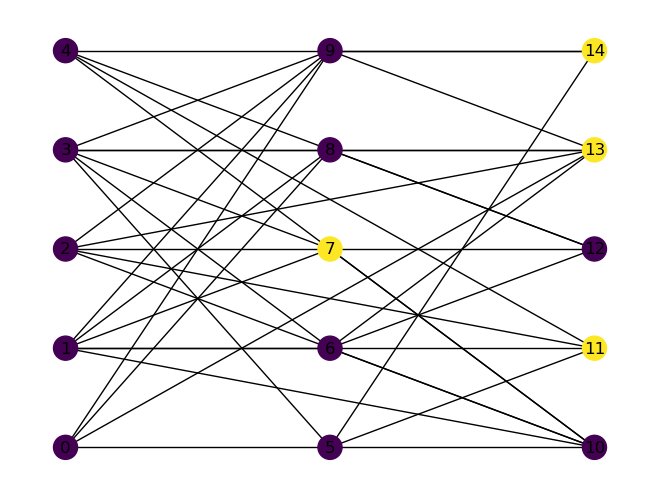

In [3]:
n = 5
G = nx.random_partition_graph([n,n,n], 0, 0.5)
pos = nx.multipartite_layout(G, subset_key="block")
csr_graph = CSRGraph.from_networkx(G, name="Complete Graph")
stable_set_problem = MaxStableSetProblem(csr_graph, A = 1.0, B = 2.0)
state, history = petford_welsh(
    problem=stable_set_problem,
    b = 4,
    max_iters = 10000,
    rng = generator,
    record_every = 10000,
)

nx.draw(G, pos=pos, node_color=[state[v] for v in G.nodes()], with_labels=True)

No candidates left at iteration 18, terminating early.
1 iterations
set()


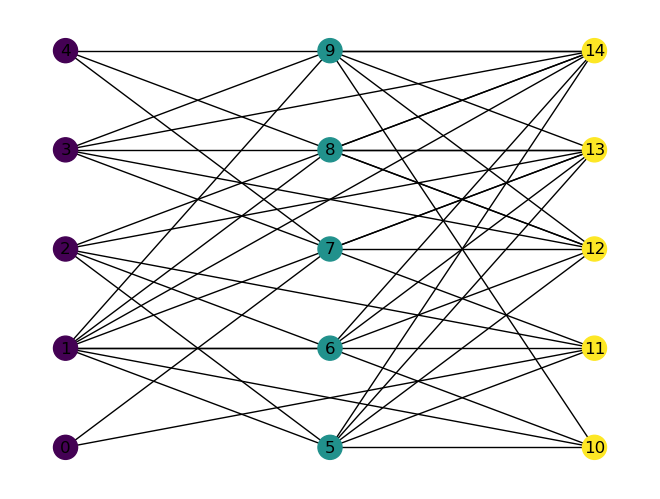

In [4]:
n = 5
G = nx.random_partition_graph([n,n,n], 0, 0.5)
pos = nx.multipartite_layout(G, subset_key="block")
csr_graph = CSRGraph.from_networkx(G, name="Complete Graph")
coloring_problem = GraphColoringProblem(csr_graph, k=3)
state, history = petford_welsh(
    problem=coloring_problem,
    b = 4,
    max_iters = 100000,
    rng = generator,
    record_every = 1000,
)
print(f"{len(history)} iterations")
print(coloring_problem.bad_vertices)
nx.draw(G, pos=pos, node_color=[state[v] for v in G.nodes()], with_labels=True)

In [5]:
# G = nx.random_partition_graph([5, 5, 5], 0, 0.3, seed=0)
# pos = nx.multipartite_layout(G, subset_key="block")
# pos = nx.spring_layout(G, seed=0)
# csr_graph = CSRGraph.from_networkx(G, name="demo")
# # problem = MaxStableSetProblem(csr_graph, A=1.0, B=2.0)
# problem = GraphColoringProblem(csr_graph, k=3)
# rng = np.random.default_rng()
# _, history = petford_welsh(problem, b=4, max_iters=100, rng=rng, record_every=1)

# fig, ax = plt.subplots(figsize=(6, 6))
# def draw(frame):
#     ax.clear()
#     nx.draw(G, pos=pos, node_color=[history[frame][v] for v in G.nodes()], with_labels=True, ax=ax)
#     ax.set_title(f"iteration {frame * 20}")

# anim = animation.FuncAnimation(fig, draw, frames=len(history), interval=150, repeat=False)
# anim.save("coloring_evolution.gif", writer="pillow")
# print(f"Saved {len(history)} frames to coloring_evolution.gif")
# plt.show()

In [61]:
import json
def benchmark(problem: MaxStableSetProblem, num_attempts: int, max_iters: int, rng: np.random.Generator, record_every: int = 1000):
    solutions = []
    for attempt in range(num_attempts):
        state, history, it = petford_welsh(
            problem=problem,
            b = 4,
            max_iters = max_iters,
            rng = rng,
            record_every = max_iters,
        )
        solutions.append(problem.best_state)
    best_solution = np.max([np.sum(s) for s in solutions])
    average_solution = np.mean([np.sum(s) for s in solutions])
    results = {
        "problem_name": problem.graph.name,
        "num_attempts": num_attempts,
        "max_iters": max_iters,
        "iterations": it,
        "A": problem.A,
        "B": problem.B,
        "b": 4,
        "best_solution": best_solution,
        "average_solution": average_solution,
    }
    path = f"results_{problem.graph.name}_A{problem.A}_B{problem.B}_b4_iters{max_iters}_attempts{num_attempts}.json"
    # with open(path, "w") as f:
    #     json.dump(results, f, indent=4)
    return best_solution, average_solution, solutions

Best solution: 13, Average solution: 11.38
Best solution (2): 13, Average solution (2): 11.44


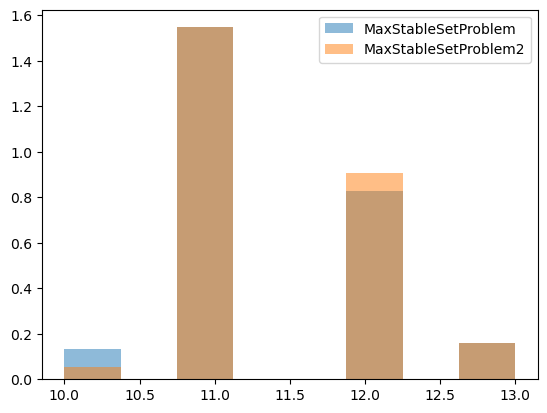

In [62]:
path = "/Users/sergejpelko/Desktop/Rudolfovo/coloring_max_stable_set/instances/stable_set/MANN_a9_stable_set_edge_list.txt"
path = "/Users/sergejpelko/Desktop/Rudolfovo/coloring_max_stable_set/instances/stable_set/brock200-4_stable_set_edge_list.txt"
G = create_networkx_graph(*read_edge_list(path))
csr_graph = CSRGraph.from_edge_list_file(path, name="MANN_a9")
stable_set_problem = MaxStableSetProblem(csr_graph, A=1.0, B=2.0)
generator = np.random.default_rng()
best_solution, average_solution, solutions = benchmark(
    problem=stable_set_problem,
    num_attempts=100,
    max_iters=10000,
    rng=generator,
)

stable_set_problem_2 = MaxStableSetProblem(csr_graph, A=1.0, B=3.0)
best_solution_2, average_solution_2, solutions_2 = benchmark(
    problem=stable_set_problem_2,
    num_attempts=100,
    max_iters=10000,
    rng=generator,
)

print(f"Best solution: {best_solution}, Average solution: {average_solution}")
print(f"Best solution (2): {best_solution_2}, Average solution (2): {average_solution_2}")
plt.hist([np.sum(s) for s in solutions], bins=8, alpha=0.5, label="MaxStableSetProblem", density=True)
plt.hist([np.sum(s) for s in solutions_2], bins=8, alpha=0.5, label="MaxStableSetProblem2", density=True)
plt.legend()
plt.show()

In [63]:
# path = "/Users/sergejpelko/Desktop/Rudolfovo/coloring_max_stable_set/instances/stable_set/MANN_a9_stable_set_edge_list.txt"
path = "/Users/sergejpelko/Desktop/Rudolfovo/coloring_max_stable_set/instances/stable_set/hamming6_2_stable_set_edge_list.txt"
csr_graph = CSRGraph.from_edge_list_file(path, name="hamming6_2")
B_values = np.linspace(1.0, 8.0, 8)
A_values = np.linspace(1.0, 8.0, 8)
best_solutions = np.zeros((len(B_values), len(A_values)))
average_solutions = np.zeros((len(B_values), len(A_values)))

for i, B in enumerate(B_values):
    for j, A in enumerate(A_values):
        stable_set_problem = MaxStableSetProblem(csr_graph, A=A, B=B)
        best_solution, average_solution, solutions = benchmark(
            problem=stable_set_problem,
            num_attempts=100,
            max_iters=1000,
            rng=generator,
        )
        best_solutions[i, j] = best_solution
        average_solutions[i, j] = average_solution

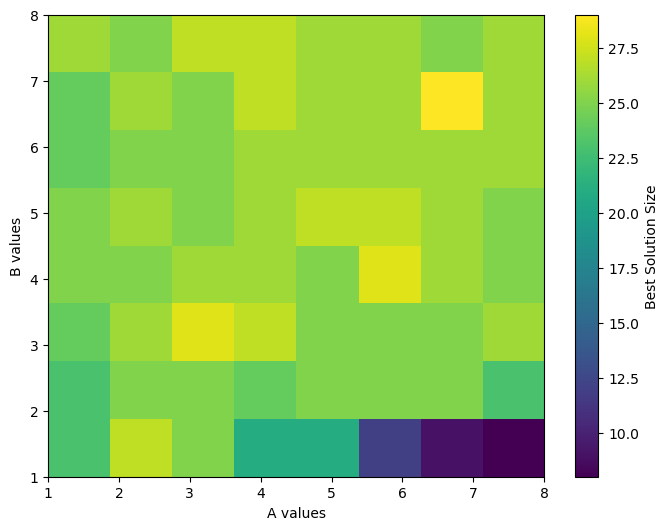

/var/folders/8h/blpn6k9s3zd_00w1r38tc2xw0000gn/T/ipykernel_24754/2432366110.py:8: RuntimeWarning: divide by zero encountered in log
  log_error = np.log(np.abs(average_solutions - np.max(average_solutions)))


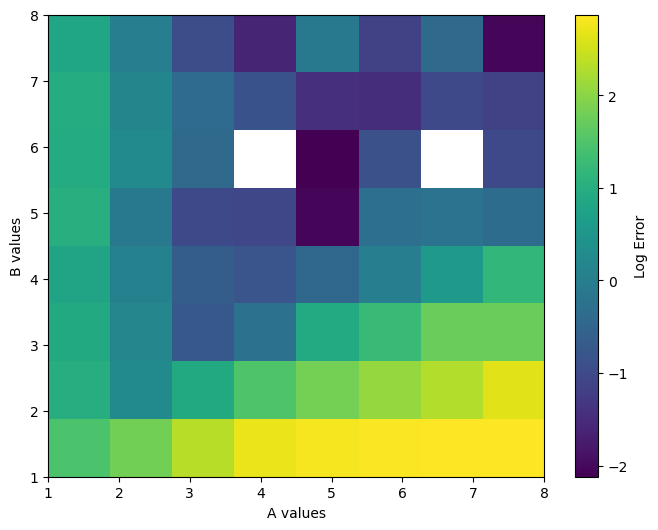

In [64]:
plt.figure(figsize=(8, 6))
plt.imshow(best_solutions, extent=[A_values[0], A_values[-1], B_values[0], B_values[-1]], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Best Solution Size')
plt.xlabel('A values')
plt.ylabel('B values')
plt.show()

log_error = np.log(np.abs(average_solutions - np.max(average_solutions)))
plt.figure(figsize=(8, 6))
plt.imshow(log_error, extent=[A_values[0], A_values[-1], B_values[0], B_values[-1]], origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(label='Log Error')
plt.xlabel('A values')
plt.ylabel('B values')
plt.show()

In [111]:
filename = "instances/stable_set/hamming6_2_stable_set_edge_list.txt"
csr_graph = CSRGraph.from_edge_list_file(filename, name="hamming6_2")
problem = MaxStableSetProblem(csr_graph, A=1.0, B=2.0)
petford_welsh(
    problem=problem,
    b = 20,
    max_iters = 1000000,
    rng = generator,
    record_every = 100000,
)
problem.best_value

27